In [1]:
import os
import sys
nb_dir = os.path.split(os.getcwd())[0]
if nb_dir not in sys.path:
    sys.path.append(nb_dir)
from soldet import SolitonDetector
import soldet
%matplotlib inline

In [12]:
import numpy as np
import matplotlib.pyplot as plt

def plot_images(data_list, title_list=None, soliton_positions=None, **plot_params): 
    '''
    Plot data in a single long image, with 6 in each row. Can box solitons if
    soliton postion information is provided.

    Parameters
    ----------
    data_list : list of 2-D numpy array
        A list of labeled images. Dimension N x 132 x 164.
    title_list : List of strings or None
        Length = N, shown as titles of images. If None, show sample with no 
        titles. If more than one plot for each image, can seperate title with \n.
    soliton_positions:
        1. List of None, tuple ((x,y), width, height) (Draw box), 
        float (Draw vertical line), list of floats (Draw vertical lines)
        
        2. Dict of the lists discribed above. the keys of them indicates the 
        color shows on the plot.
        
    **plot_params: dictionary
        plot_profile: Boolean. Default False. If add plot of the profile data.
                      Or String: 'm_hat1D', 'gaussian1D'
        plot_fullrange: Boolean. Default False. If add plot of the data in [0, 1] range
        plot_per_row: int. Default: 6
    Returns
    -------
    None.

    '''
    
    if 'plot_profile' in plot_params:
        plot_profile = plot_params['plot_profile']
    else:
        plot_profile = False
        
    if 'plot_profile_fit' in plot_params:
        plot_profile_fit = plot_params['plot_profile_fit']
    else:
        plot_profile_fit = 'm_hat1D'

    if soliton_positions is None:
        plot_soliton = False
    elif type(soliton_positions) == dict:
        plot_soliton = 'color'
    else:
        plot_soliton = 'red'
    
    if 'plot_fullrange' in plot_params:
        plot_fullrange = plot_params['plot_fullrange']
    else:
        plot_fullrange = False
        
    if 'plot_per_row' in plot_params:
        plot_per_row = plot_params['plot_per_row']
    else:
        plot_per_row = 6
    
    if 'title_font_size' in plot_params:
        title_font_size = plot_params['title_font_size']
    else:
        title_font_size = 8
    
    if 'return_fig' in plot_params:
        return_fig = plot_params['return_fig']
    else:
        return_fig = False
        
    if 'profile_ylim' in plot_params:
        profile_ylim = plot_params['profile_ylim']
    else:
        profile_ylim = False
        
    if 'figure_zlim' in plot_params:
        figure_zlim = plot_params['figure_zlim']
    else:
        figure_zlim = False
    
    if 'vertical_arrange' in plot_params:
        vertical_arrange = plot_params['vertical_arrange']
    else:
        vertical_arrange = False
        
    if 'print_pdf' in plot_params:
        print_pdf = plot_params['print_pdf']
    else:
        print_pdf = False
        
    if 'add_vertical_space' in plot_params:
        add_vertical_space = plot_params['add_vertical_space']
    else:
        add_vertical_space = False
    
    if 'figure_width' in plot_params:
        figure_width = plot_params['figure_width']
    else:
        figure_width = 7.2
    
    if 'lw' in plot_params:
        lw = plot_params['lw']
    else:
        lw = 1
    
    plot_per_image = 1
    if plot_profile==True:
        plot_per_image += 1
    elif plot_profile=='Two':
        plot_per_image += 2
    if plot_fullrange:
        plot_per_image += 1
    
    
    n_img = len(data_list) * plot_per_image
    n_row = int(np.ceil(n_img / plot_per_row))
    # if vertical_arrange:
    #     n_row += plot_per_image-1
    fig = plt.figure(figsize=(figure_width, (figure_width/7.2)*n_row))
    k=0
    cmap = plt.get_cmap('Greys') # viridis (default), 
        
    for i, roi in enumerate(data_list):
        # Plot original image
        if title_list == None:
            titles = ['']*plot_per_image
        else:
            titles = title_list[i].split('\n')
            for j in range(max(0, plot_per_image-len(titles))):
                titles.append('')
                
        if vertical_arrange:
            plt.subplot(n_row, plot_per_row, (i + 1)+plot_per_row*(plot_per_image-1)*(i//plot_per_row))
            plt.title(titles[k % plot_per_image], fontsize=title_font_size, loc='left')
        else:
            plt.subplot(n_row, plot_per_row, k + 1)
            plt.title(titles[k % plot_per_image], fontsize=title_font_size)
            k+=1
            
        roi_plot = np.array(roi).reshape((132,164))
        if add_vertical_space:
            newrow = np.full((add_vertical_space, 164), roi_plot[0,0])
            roi_plot = np.vstack([newrow, roi_plot, newrow])
        
        if figure_zlim:
            plt.pcolormesh(roi_plot, vmin=figure_zlim[0], vmax=figure_zlim[1], rasterized=True, cmap=cmap)
        else:
            plt.pcolormesh(roi_plot, rasterized=True, cmap=cmap)
            
        if plot_soliton == 'red': 
            ax = plt.gca()
            draw_solitons(ax, soliton_positions[i], add_vertical_space=add_vertical_space)
        elif plot_soliton == 'color':
            ax = plt.gca()
            for color, soliton_position in soliton_positions.items():
                draw_solitons(ax, soliton_position[i], **{'color': color}, add_vertical_space=add_vertical_space)
        
        plt.xticks(())
        plt.yticks(())
        
        # Plot image in [0,1] full range
        if plot_fullrange:
            if vertical_arrange:
                plt.subplot(n_row, plot_per_row, (i + 7)+plot_per_row*(plot_per_image-1)*(i//plot_per_row))
                plt.title(titles[k % plot_per_image], fontsize=title_font_size)
            else:
                plt.subplot(n_row, plot_per_row, k + 1)
                plt.title(titles[k % plot_per_image], fontsize=title_font_size)
                k+=1
            
            plt.pcolormesh(roi_plot,vmin=0, vmax=1, rasterized=True, cmap=cmap)
            if plot_soliton == 'red': 
                ax = plt.gca()
                draw_solitons(ax, soliton_positions[i])
            elif plot_soliton == 'color':
                ax = plt.gca()
                for color, soliton_position in soliton_positions.items():
                    draw_solitons(ax, soliton_position[i], **{'color': color}, add_vertical_space=add_vertical_space)
            plt.xticks(())
            plt.yticks(())
            
            
        # Plot 1-D profile of the image
        if plot_profile==True:
            vec_x, vec_y, roixwithoutbackg, res = fit_tf_1D_from_image(roi)
            
            if vertical_arrange:
                plt.subplot(n_row, plot_per_row, (i + 1+6*(plot_per_image-1))+plot_per_row*(plot_per_image-1)*(i//plot_per_row))
                # plt.title(titles[k % plot_per_image], fontsize=title_font_size)
            else:
                plt.subplot(n_row, plot_per_row, k + 1)
                plt.title(titles[k % plot_per_image], fontsize=title_font_size)
                k+=1
            
            plt.plot(roixwithoutbackg, "-b", label="", linewidth=lw)
            plt.plot(vec_y - res["offset"], "-g", label="", linewidth=lw)
            plt.plot(res["fitfunc"](vec_x) - res["offset"], '-k', linewidth=lw)
            plt.plot(vec_x,np.repeat(0, len(roixwithoutbackg)),'--k', linewidth=lw)
            if profile_ylim:
                plt.ylim(profile_ylim)
                if vertical_arrange and i%plot_per_row!=0:
                    plt.yticks(())
            
            if plot_soliton == 'red': 
                ax = plt.gca()
                draw_solitons(ax, soliton_positions[i], **{'dims':1})
                if type(plot_profile_fit) is str:
                    if type(soliton_positions[i]) is not list:
                        soliton_positions[i] = [soliton_positions[i]]
                    for p in soliton_positions[i]:
                        plt.plot(fit_soliton(vec_x, roixwithoutbackg, inti_pos=p, func=plot_profile_fit, return_fit_curve=True),"-",color='purple', label="", linewidth=lw)
            
            elif plot_soliton == 'color':
                ax = plt.gca()
                for color, soliton_position in soliton_positions.items():
                    draw_solitons(ax, soliton_position[i], 
                                  **{'dims':1, 'color': color})
                    
            plt.xticks(())
            if vertical_arrange and i > (len(data_list)-plot_per_row-1):
                plt.xticks((0, 164))
            plt.xlim([0, 164])
            
        elif plot_profile=='Two':
        
            bottom_mask=np.zeros_like(roi)
            bottom_mask[:int(bottom_mask.shape[0]/2),:]=1
            top_mask=np.zeros_like(roi)
            top_mask[int(top_mask.shape[0]/2):,:]=1
            
            top_prod = np.multiply(roi,top_mask)
            bottom_prod = np.multiply(roi,bottom_mask)
            
            vec_x, vec_y, roixwithoutbackg, res = fit_tf_1D_from_image(top_prod)
            
            # if vertical_arrange:
            #     plt.subplot(n_row, plot_per_row, (i + 1+6*(plot_per_image-1))+plot_per_row*(plot_per_image-1)*(i//plot_per_row))
            #     # plt.title(titles[k % plot_per_image], fontsize=title_font_size)
            # else:
                
            plt.subplot(n_row, plot_per_row, k + 1)
            plt.title(titles[k % plot_per_image], fontsize=title_font_size)
            k+=1
            
            plt.plot(roixwithoutbackg, "-b", label="", linewidth=lw)
            plt.plot(vec_y - res["offset"], "-g", label="", linewidth=lw)
            plt.plot(res["fitfunc"](vec_x) - res["offset"], '-k', linewidth=lw)
            plt.plot(vec_x,np.repeat(0, len(roixwithoutbackg)),'--k', linewidth=lw)
            if profile_ylim:
                plt.ylim(profile_ylim)
                if vertical_arrange and i%plot_per_row!=0:
                    plt.yticks(())
            
            if plot_soliton == 'red': 
                ax = plt.gca()
                draw_solitons(ax, soliton_positions[i], **{'dims':1})
                if type(plot_profile_fit) is str:
                    if type(soliton_positions[i]) is not list:
                        soliton_positions[i] = [soliton_positions[i]]
                    for p in soliton_positions[i]:
                        plt.plot(fit_soliton(vec_x, roixwithoutbackg, inti_pos=p, func=plot_profile_fit, return_fit_curve=True),"-",color='purple', label="", linewidth=lw)
            
            elif plot_soliton == 'color':
                ax = plt.gca()
                for color, soliton_position in soliton_positions.items():
                    draw_solitons(ax, soliton_position[i], 
                                  **{'dims':1, 'color': color})
                    
            plt.xticks(())
            # if vertical_arrange and i > (len(data_list)-plot_per_row-1):
            #     plt.xticks((0, 164))
            plt.xlim([0, 164])
            
            vec_x, vec_y, roixwithoutbackg, res = fit_tf_1D_from_image(bottom_prod)
            
            # if vertical_arrange:
            #     plt.subplot(n_row, plot_per_row, (i + 1+6*(plot_per_image-1))+plot_per_row*(plot_per_image-1)*(i//plot_per_row))
            #     # plt.title(titles[k % plot_per_image], fontsize=title_font_size)
            # else:
                
            plt.subplot(n_row, plot_per_row, k + 1)
            plt.title(titles[k % plot_per_image], fontsize=title_font_size)
            k+=1
            
            plt.plot(roixwithoutbackg, "-b", label="", linewidth=lw)
            plt.plot(vec_y - res["offset"], "-g", label="", linewidth=lw)
            plt.plot(res["fitfunc"](vec_x) - res["offset"], '-k', linewidth=lw)
            plt.plot(vec_x,np.repeat(0, len(roixwithoutbackg)),'--k', linewidth=lw)
            if profile_ylim:
                plt.ylim(profile_ylim)
                if vertical_arrange and i%plot_per_row!=0:
                    plt.yticks(())
            
            if plot_soliton == 'red': 
                ax = plt.gca()
                draw_solitons(ax, soliton_positions[i], **{'dims':1})
                if type(plot_profile_fit) is str:
                    if type(soliton_positions[i]) is not list:
                        soliton_positions[i] = [soliton_positions[i]]
                    for p in soliton_positions[i]:
                        plt.plot(fit_soliton(vec_x, roixwithoutbackg, inti_pos=p, func=plot_profile_fit, return_fit_curve=True),"-",color='purple', label="", linewidth=lw)
            
            elif plot_soliton == 'color':
                ax = plt.gca()
                for color, soliton_position in soliton_positions.items():
                    draw_solitons(ax, soliton_position[i], 
                                  **{'dims':1, 'color': color})
                    
            plt.xticks(())
            # if vertical_arrange and i > (len(data_list)-plot_per_row-1):
            #     plt.xticks((0, 164))
            plt.xlim([0, 164])
            
            
    # fig.tight_layout()
    plt.subplots_adjust(hspace=0.5)
    if print_pdf:
        plt.savefig(print_pdf+'.pdf', bbox_inches='tight') 
    
    if return_fig:
        return fig
    else:
        plt.show()
    

In [6]:
def preview_data(self, data_key, n=9, seed=None, sample='labels', **plot_params): #TODO
        '''
        Plot a sample from dataset.

        Parameters
        ----------
        data: str
            Keyword for target dataset.
        n: int
            Total number of data sample. The default is 9.
        seed : int
            seed for select sample data. The default is None.
        sample: str
            method to select data. The default is 'class'.
                'class': evenly sample in each class
                'random': random sample in whole dataset
        **data_params : dict
            See DESCRIPTION for soldet.plot_images

        Returns
        -------
        Figure.
        '''
        import matplotlib.pyplot as plt
        import numpy as np
        # Select data
        data = self.data[data_key]['data']
        labels = self.data[data_key]['labels'] if 'labels' in self.data[data_key] else None
        positions = self.data[data_key]['positions'] if 'positions' in self.data[data_key] else None
        types = self.data[data_key]['types'] if 'types' in self.data[data_key] else None

        # Set random seed
        if seed is not None:
            np.random.seed(seed)

        # Sample indices
        if sample == 'class' and labels is not None:
            unique_labels = np.unique(labels)
            idx = []
            per_class = max(1, n // len(unique_labels))
            for ul in unique_labels:
                class_idx = np.where(np.array(labels) == ul)[0]
                if len(class_idx) > 0:
                    idx.extend(np.random.choice(class_idx, min(per_class, len(class_idx)), replace=False))
            idx = np.array(idx)
            if len(idx) > n:
                idx = idx[:n]
        else:
            idx = np.random.choice(len(data), n, replace=False)

        # Prepare samples
        sample_data = [data[i] for i in idx]
        sample_labels = [labels[i] for i in idx] if labels is not None else None
        sample_positions = [positions[i] for i in idx] if positions is not None else None
        sample_types = [types[i] for i in idx] if types is not None else None

        print(f"preview_data: data_key={data_key}, n={n}, sample={sample}, seed={seed}")
        print(f"data length: {len(data)}")
        if labels is not None:
            print(f"labels length: {len(labels)}, unique labels: {np.unique(labels)}")
        if positions is not None:
            print(f"positions length: {len(positions)}")
        if types is not None:
            print(f"types length: {len(types)}")

        # After selecting indices
        print(f"Selected indices: {idx}")

        # After preparing samples
        print(f"sample_data length: {len(sample_data)}")
        if sample_labels is not None:
            print(f"sample_labels: {sample_labels}")
        if sample_positions is not None:
            print(f"sample_positions: {sample_positions}")
        if sample_types is not None:
            print(f"sample_types: {sample_types}")
        print("Calling plot_images...")

        # Plot images using soldet.plot_images
        fig = plot_images(sample_data, labels=sample_labels, positions=sample_positions, types=sample_types, **plot_params)

                # After plot_images
        print(f"plot_images returned: {fig}")

        plt.show()
        return fig

In [2]:
import importlib
import soldet
importlib.reload(soldet)
from soldet.SolitonDetector import SolitonDetector

In [15]:
# Define SolitonDetector object
sd = SolitonDetector()
# Data loading
labeled_data_dir = [nb_dir + '/data/data_files/class-' + s +'/' for s in ['0','1','2','9']]
sd.load_data(directory=labeled_data_dir, data_key={'train':0.9, 'test':0.1}, data_type='labeled', shuffle=420) # load labeled data, 
# sd.preview_data() # show sample data for each class

100%|██████████| 15599/15599 [02:22<00:00, 109.77it/s]


Total number of samples : 15599


preview_data: data_key=train, n=9, sample=labels, seed=None
data length: 4840
labels length: 4840, unique labels: [0 1 2]
positions length: 4840
types length: 4840
Selected indices: [4003 4226 3213 2004  756 3078 3451 4557 3762]
sample_data length: 9
sample_labels: [1, 0, 1, 0, 1, 2, 1, 2, 2]
sample_positions: [[50.7384692706405], [], [92.36446721396567], [], [82.33054456757377], '', [97.87226924361485], '', '']
sample_types: [[0], [], [0], [], [0], '', [0], '', '']
Calling plot_images...


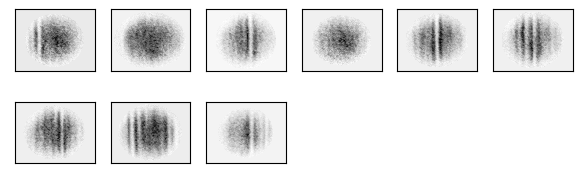

plot_images returned: None


In [14]:
preview_data(sd,data_key='train')

In [11]:
# Training ML models:
sd.train_ML(model_key='object_detector', data_key='train', save=nb_dir+'/example/SolDet_train/') # train object detector.
sd.train_ML(model_key='classifier', data_key='train', save=nb_dir+'/example/SolDet_train/') # train CNN classifier.

Epoch 1/50
421/488 [========================>.....] - ETA: 15s - loss: 197.1297 - f1_41: 0.5577

KeyboardInterrupt: 

In [ ]:
# Training Physics-based models:
sd.define_PIE_classifier(data_key='train', save=nb_dir+'/example/SolDet_train/') # define PIE classifier
sd.train_quality_estimator(data_key='train', save=nb_dir+'/example/SolDet_train/') # define quality estimator

In [ ]:
# Testing
sd.load_models(nb_dir+'/example/SolDet/')
model_keys = ['classifier', 'object_detector', 'PIE_classifier', 'quality_estimator']
results = []
for model_key in model_keys:
    results.append(sd.predict(data_key='test', model_key=model_key))